# 06 — Soil Profile Features (SSURGO via SDA)

Fetches soil attributes from the USDA **Soil Data Access (SDA)** API for every
coffee plot centroid. Saves `plot_soil_features.pkl` for merging into the
feature matrix in notebook 05.

**Strategy:**
1. One bounding-box query to pull all ~510 SSURGO map units in the region —
   gives us `mukey → attributes` for free.
2. One point query per coffee cell centroid (385 calls ≈20 seconds total with
   concurrent requests) to resolve `plot_id → mukey`.
3. Local join.

**Features extracted:**

| Column | Description |
|---|---|
| `taxorder` | Soil order (Andisol, Inceptisol, Histosol …) |
| `taxsubgrp` | Subgroup |
| `drainagecl` | Drainage class (text) |
| `drain_ord` | Drainage class as ordinal (0=excessive → 6=very poorly) |
| `restrictiondepth_cm` | Depth to bedrock / hardpan (cm) |
| `awc_mean` | Available water capacity (cm/cm, mean across horizons) |
| `ph_0_30cm` | pH in 1:1 water, 0–30 cm |
| `om_0_30cm` | Organic matter %, 0–30 cm |
| `soil_null` | 1 = plot on young lava / no SSURGO soil mapped |

> **Background cells:** This notebook queries coffee cells only. To add soil to
> the topo binary classifier (notebook 07), download the SSURGO shapefile for
> Hawaii County from WebSoilSurvey and spatial-join it to the full grid.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import requests
import time
import json
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'

SDA_URL = "https://sdmdataaccess.nrcs.usda.gov/Tabular/post.rest"

def sda_query(sql, timeout=120):
    """POST a T-SQL query to SDA and return a DataFrame."""
    r = requests.post(SDA_URL,
                      data={"query": sql, "format": "json+columnname"},
                      timeout=timeout)
    r.raise_for_status()
    j = r.json()
    if "Table" not in j or not j["Table"]:
        return pd.DataFrame()
    cols = j["Table"][0]
    rows = j["Table"][1:]
    return pd.DataFrame(rows, columns=cols)

# ── Quick connectivity test ────────────────────────────────────────────────────
test = sda_query("SELECT TOP 1 mukey, muname FROM mapunit")
print("SDA connection OK:", test.iloc[0].to_dict())


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


SDA connection OK: {'mukey': '49456', 'muname': 'Sarkar-McGilvery complex, 75 to 120 percent slopes'}


In [2]:
# ── Load all grid cell centroids ──────────────────────────────────────────────
# Use the full 10,211-cell grid (not coffee-only) so soil coverage extends to
# all cells for the island-wide suitability map.
# df.pkl is still loaded here for the exploratory EDA cells below.
df        = pd.read_pickle(f'{DATA}/df.pkl')
elev_feat = pd.read_pickle(f'{DATA}/plot_elev_features.pkl')

gdf_all = gpd.GeoDataFrame(
    elev_feat[['plot_id', 'geometry']], geometry='geometry', crs='EPSG:4326'
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gdf_all = gdf_all.copy()
    gdf_all['lon'] = gdf_all.geometry.centroid.x
    gdf_all['lat'] = gdf_all.geometry.centroid.y

print(f'{len(gdf_all)} grid cell centroids loaded (full island grid)')
print(f'Lon range: {gdf_all.lon.min():.4f} – {gdf_all.lon.max():.4f}')
print(f'Lat range: {gdf_all.lat.min():.4f} – {gdf_all.lat.max():.4f}')

10211 grid cell centroids loaded (full island grid)
Lon range: -156.0046 – -155.4384
Lat range: 19.0430 – 19.7570


In [3]:
# ── Step 1: fetch all mukey attributes for the region in one query ─────────────
# Bounding box covers the full Big Island — expanded from coffee-belt-only so
# soil data populates the island-wide suitability map in 04_similarity_search.
# Young lava flows / unmapped areas will return no mukey (soil_null=1).
BBOX_WKT = 'POLYGON((-156.1 18.9, -154.7 18.9, -154.7 20.3, -156.1 20.3, -156.1 18.9))'

mukey_sql = f"""
SELECT DISTINCT mu.mukey
FROM mapunit mu
WHERE mu.mukey IN (
    SELECT mukey FROM SDA_Get_Mukey_from_intersection_with_WktWgs84('{BBOX_WKT}')
)
"""

attr_sql = f"""
SELECT
    mu.mukey,
    mu.muname,
    c.compname,
    c.comppct_r,
    c.taxorder,
    c.taxsubgrp,
    c.drainagecl,
    (SELECT MIN(cr.resdept_r)
     FROM corestrictions cr WHERE cr.cokey = c.cokey) AS restrictiondepth_cm,
    (SELECT AVG(ch.awc_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.awc_r IS NOT NULL) AS awc_mean,
    (SELECT AVG(ch.ph1to1h2o_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.ph1to1h2o_r IS NOT NULL) AS ph_0_30cm,
    (SELECT AVG(ch.om_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.om_r IS NOT NULL) AS om_0_30cm,
    (SELECT AVG(ch.sandtotal_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.sandtotal_r IS NOT NULL) AS sand_0_30cm,
    (SELECT AVG(ch.silttotal_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.silttotal_r IS NOT NULL) AS silt_0_30cm,
    (SELECT AVG(ch.claytotal_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.claytotal_r IS NOT NULL) AS clay_0_30cm,
    (SELECT AVG(ch.cec7_r)
     FROM chorizon ch WHERE ch.cokey = c.cokey
     AND ch.hzdept_r < 30 AND ch.cec7_r IS NOT NULL) AS cec_0_30cm
FROM mapunit mu
INNER JOIN component c ON mu.mukey = c.mukey AND c.majcompflag = 'Yes'
WHERE mu.mukey IN (
    SELECT mukey FROM SDA_Get_Mukey_from_intersection_with_WktWgs84('{BBOX_WKT}')
)
ORDER BY mu.mukey, c.comppct_r DESC
"""

print('Fetching all map unit attributes in region...')
mu_attrs = sda_query(attr_sql, timeout=180)

# Keep only dominant component per mukey (already sorted by comppct_r DESC)
mu_attrs_dedup = mu_attrs.drop_duplicates(subset='mukey', keep='first').copy()

print(f'Retrieved {len(mu_attrs_dedup)} unique map units')
print('Soil orders present:')
print(mu_attrs_dedup['taxorder'].value_counts(dropna=False).head(10))

Fetching all map unit attributes in region...
Retrieved 600 unique map units
Soil orders present:
Andisols       413
Histosols       76
NaN             64
Entisols        21
Inceptisols     13
Aridisols        7
Mollisols        6
Name: taxorder, dtype: int64


In [4]:
# ── Step 2: resolve plot_id → mukey via concurrent point queries ──────────────
# Uses a thread pool to run ~10 requests in parallel.
# With 10,211 cells this takes ~3–6 minutes (vs ~30s for coffee-only).

def fetch_mukey(row):
    """Return (plot_id, mukey_or_None) for a single centroid."""
    plot_id, lon, lat = row['plot_id'], row['lon'], row['lat']
    sql = f"""SELECT mukey
              FROM SDA_Get_Mukey_from_intersection_with_WktWgs84(
                  'POINT({lon} {lat})')"""
    try:
        df_res = sda_query(sql, timeout=30)
        if len(df_res) == 0:
            return plot_id, None
        return plot_id, df_res['mukey'].iloc[0]
    except Exception as e:
        return plot_id, None

rows = gdf_all[['plot_id','lon','lat']].to_dict('records')

results = {}
failed  = []

print(f'Querying mukeys for {len(rows)} grid cells (10 threads)...')
with ThreadPoolExecutor(max_workers=10) as pool:
    futures = {pool.submit(fetch_mukey, r): r['plot_id'] for r in rows}
    for i, fut in enumerate(as_completed(futures), 1):
        plot_id, mukey = fut.result()
        results[plot_id] = mukey
        if mukey is None:
            failed.append(plot_id)
        if i % 500 == 0 or i == len(rows):
            print(f'  {i}/{len(rows)}  ({len(failed)} no-soil so far)')

print(f'\nDone. {len(failed)} cells returned no mukey (ocean / lava / unmapped).')

Querying mukeys for 10211 grid cells (10 threads)...
  500/10211  (0 no-soil so far)
  1000/10211  (0 no-soil so far)
  1500/10211  (0 no-soil so far)
  2000/10211  (4 no-soil so far)
  2500/10211  (4 no-soil so far)
  3000/10211  (4 no-soil so far)
  3500/10211  (18 no-soil so far)
  4000/10211  (40 no-soil so far)
  4500/10211  (95 no-soil so far)
  5000/10211  (112 no-soil so far)
  5500/10211  (112 no-soil so far)
  6000/10211  (141 no-soil so far)
  6500/10211  (167 no-soil so far)
  7000/10211  (167 no-soil so far)
  7500/10211  (167 no-soil so far)
  8000/10211  (177 no-soil so far)
  8500/10211  (178 no-soil so far)
  9000/10211  (178 no-soil so far)
  9500/10211  (178 no-soil so far)
  10000/10211  (178 no-soil so far)
  10211/10211  (178 no-soil so far)

Done. 178 cells returned no mukey (ocean / lava / unmapped).


In [5]:
# ── Step 3: join plot → mukey → attributes ────────────────────────────────────
plot_mukey = pd.DataFrame(list(results.items()), columns=['plot_id', 'mukey'])

soil_df = plot_mukey.merge(mu_attrs_dedup, on='mukey', how='left')

# ── Numeric coercion ──────────────────────────────────────────────────────────
for col in ['restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
            'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm', 'comppct_r']:
    soil_df[col] = pd.to_numeric(soil_df[col], errors='coerce')

# ── Drainage class ordinal encoding ──────────────────────────────────────────
DRAIN_ORD = {
    'Excessively drained':          0,
    'Somewhat excessively drained': 1,
    'Well drained':                 2,
    'Moderately well drained':      3,
    'Somewhat poorly drained':      4,
    'Poorly drained':               5,
    'Very poorly drained':          6,
}
soil_df['drain_ord'] = soil_df['drainagecl'].map(DRAIN_ORD)

# ── No-soil flag ──────────────────────────────────────────────────────────────
soil_df['soil_null'] = soil_df['mukey'].isna().astype(int)

# ── Final feature set ─────────────────────────────────────────────────────────
SOIL_FEAT_COLS = [
    'plot_id', 'mukey', 'muname', 'compname',
    'taxorder', 'taxsubgrp', 'drainagecl', 'drain_ord',
    'restrictiondepth_cm', 'awc_mean',
    'ph_0_30cm', 'om_0_30cm',
    'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm',
    'soil_null',
]

plot_soil = soil_df[SOIL_FEAT_COLS].copy()

print('Soil features shape:', plot_soil.shape)
print('\nNull counts:')
print(plot_soil[['restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm',
                 'drain_ord', 'sand_0_30cm', 'silt_0_30cm', 'clay_0_30cm', 'cec_0_30cm']].isna().sum())
print('\nSample rows:')
print(plot_soil.head(3).to_string())

Soil features shape: (10211, 17)

Null counts:
restrictiondepth_cm    1544
awc_mean                178
ph_0_30cm               877
om_0_30cm               877
drain_ord               202
sand_0_30cm            3659
silt_0_30cm            3659
clay_0_30cm            3659
cec_0_30cm             1458
dtype: int64

Sample rows:
   plot_id    mukey                                               muname    compname taxorder taxsubgrp    drainagecl  drain_ord  restrictiondepth_cm  awc_mean  ph_0_30cm  om_0_30cm  sand_0_30cm  silt_0_30cm  clay_0_30cm  cec_0_30cm  soil_null
0        8  2371228  Lava flows-Kanohina complex, 2 to 20 percent slopes  Lava flows     None      None  Well drained        2.0                  0.0       0.0        NaN        NaN          NaN          NaN          NaN         NaN          0
1        0  2371228  Lava flows-Kanohina complex, 2 to 20 percent slopes  Lava flows     None      None  Well drained        2.0                  0.0       0.0        NaN        NaN     

In [6]:
# ── Exploratory: soil profile by region ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

BG = 'white'

# Drop any stale soil columns that may exist in df.pkl from a previous run
_SOIL_DROP = ['drain_ord','restrictiondepth_cm','awc_mean','ph_0_30cm','om_0_30cm',
              'soil_null','mukey','muname','compname','taxorder','taxsubgrp','drainagecl']
df_clean   = df.drop(columns=[c for c in _SOIL_DROP if c in df.columns])
df_merged  = df_clean.merge(plot_soil, on='plot_id', how='left')

print('=== Soil orders by region ===')
print(df_merged.groupby('region')['taxorder'].value_counts(dropna=False).to_string())

print('\n=== Drainage class by region ===')
print(df_merged.groupby('region')['drainagecl'].value_counts(dropna=False).to_string())

print('\n=== Numeric soil features by region ===')
soil_num = ['restrictiondepth_cm','awc_mean','ph_0_30cm','om_0_30cm']
print(df_merged.groupby('region')[soil_num].describe().round(2).to_string())


=== Soil orders by region ===
region  taxorder 
kau     Andisols      62
kona    Andisols     255
        Histosols     64
        Mollisols      3
        NaN            1

=== Drainage class by region ===
region  drainagecl                  
kau     Well drained                     60
        Somewhat excessively drained      2
kona    Well drained                    261
        Moderately well drained          29
        Somewhat poorly drained          25
        Somewhat excessively drained      7
        Excessively drained               1

=== Numeric soil features by region ===
       restrictiondepth_cm                                              awc_mean                                          ph_0_30cm                                        om_0_30cm                                             
                     count   mean    std   min   25%   50%   75%    max    count  mean   std   min   25%  50%   75%   max     count  mean   std   min   25%  50%  75%  max     count 

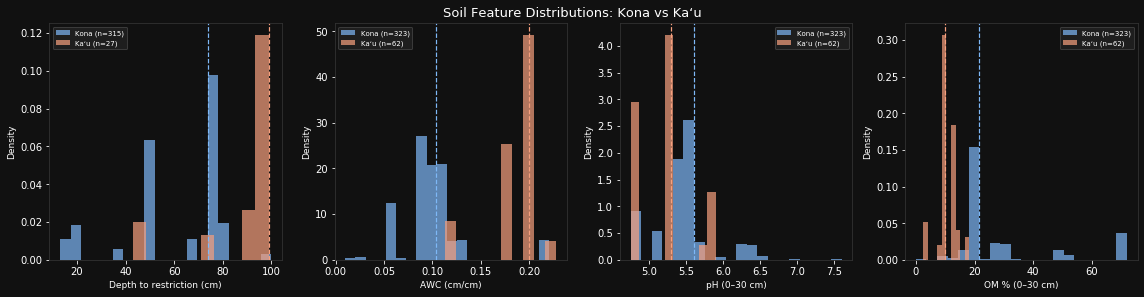

In [7]:
# ── Kona vs Kaʻu soil feature distributions ────────────────────────────────────
soil_num = ['restrictiondepth_cm', 'awc_mean', 'ph_0_30cm', 'om_0_30cm']
soil_labels = ['Depth to restriction (cm)', 'AWC (cm/cm)', 'pH (0–30 cm)', 'OM % (0–30 cm)']

kona_s = df_merged[df_merged.region == 'kona']
kau_s  = df_merged[df_merged.region == 'kau']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor(BG)

for ax, col, label in zip(axes, soil_num, soil_labels):
    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    kdata = kona_s[col].dropna()
    udata = kau_s[col].dropna()

    if len(kdata) > 0:
        ax.hist(kdata, bins=20, color='#7eb8f7', alpha=0.7, density=True,
                edgecolor='none', label=f'Kona (n={len(kdata)})')
        ax.axvline(kdata.median(), color='#7eb8f7', linestyle='--', linewidth=1.2)
    if len(udata) > 0:
        ax.hist(udata, bins=10, color='#f7a07e', alpha=0.7, density=True,
                edgecolor='none', label=f"Kaʻu (n={len(udata)})")
        ax.axvline(udata.median(), color='#f7a07e', linestyle='--', linewidth=1.2)

    ax.set_xlabel(label, color='#222222', fontsize=9)
    ax.set_ylabel('Density', color='#222222', fontsize=9)
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc', fontsize=7)
    for _t in _leg.get_texts(): _t.set_color('#222222')

fig.suptitle('Soil Feature Distributions: Kona vs Kaʻu', color='#222222', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG}/10_soil_distributions.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


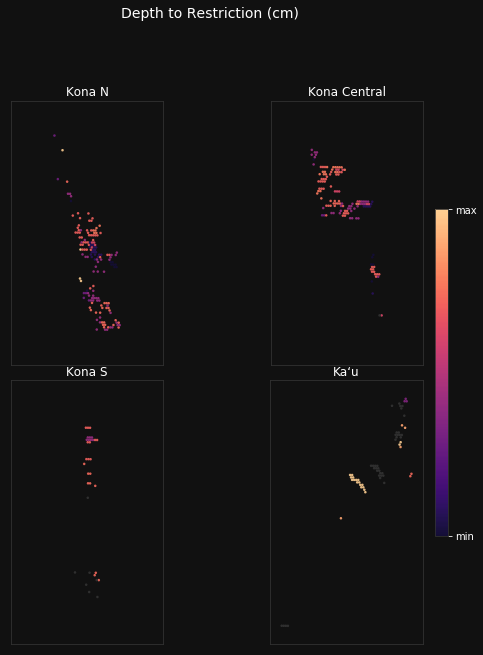

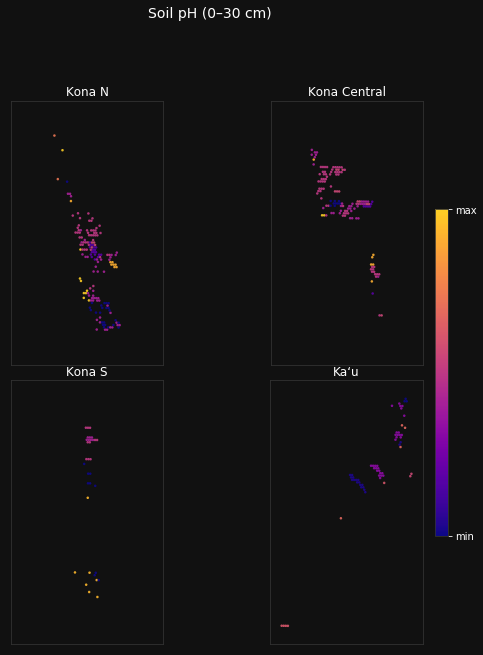

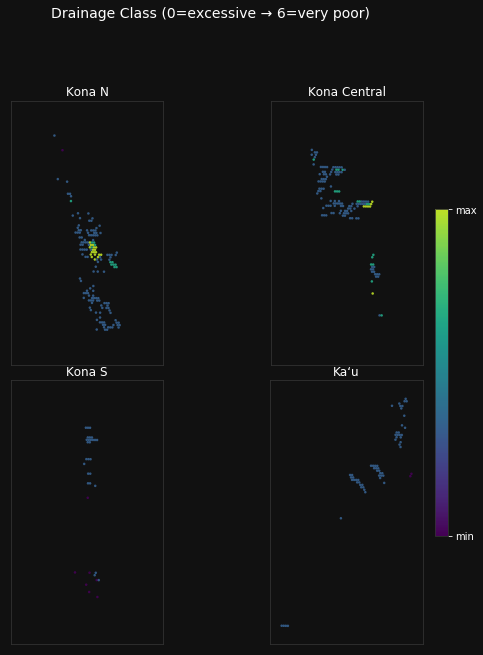

In [8]:
# ── Spatial maps of soil attributes ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

SPLIT_LON = -155.7279

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))

def plot_regions(gdf, col, title, cmap, fname):
    cx = gdf.geometry.centroid.x
    cy = gdf.geometry.centroid.y
    kona = gdf[cx < SPLIT_LON]
    kau  = gdf[cx >= SPLIT_LON]
    kona_cy = cy[kona.index]
    lat_min, lat_max = kona_cy.min(), kona_cy.max()
    cut1 = lat_min + (lat_max - lat_min) / 3
    cut2 = lat_min + 2 * (lat_max - lat_min) / 3
    kona_n = kona[kona_cy >= cut2]
    kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
    kona_s = kona[kona_cy < cut1]
    ab = kau.total_bounds
    span_w = (ab[2]-ab[0]) * 1.15
    span_h = (ab[3]-ab[1]) * 1.15
    def cb(r):
        b = r.total_bounds; return (b[0]+b[2])/2, (b[1]+b[3])/2
    panels = [(kona_n,'Kona N'),(kona_m,'Kona Central'),(kona_s,'Kona S'),(kau,"Kaʻu")]
    valid = gdf[col].dropna()
    vmin, vmax = valid.quantile(0.02), valid.quantile(0.98)
    fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                             gridspec_kw={'hspace':0.06,'wspace':0.04})
    fig.patch.set_facecolor(BG)
    for ax, (region, label) in zip(axes.flat, panels):
        rx, ry = cb(region)
        ax.set_facecolor(BG)
        region.plot(ax=ax, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
                    legend=False, edgecolor='none', alpha=0.9, missing_kwds={'color':'#333333'})
        ax.set_xlim(rx-span_w/2, rx+span_w/2)
        ax.set_ylim(ry-span_h/2, ry+span_h/2)
        ax.set_title(label, fontsize=12, pad=5, color='#222222')
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(['min', 'max'])
    cbar.ax.yaxis.set_tick_params(color='#222222', labelsize=10)
    for _t in cbar.ax.yaxis.get_ticklabels(): _t.set_color('#222222')
    cbar.outline.set_edgecolor('#333333')
    fig.suptitle(title, fontsize=14, color='#222222', y=1.01)
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

grid   = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf_s  = gpd.GeoDataFrame(
    grid.merge(df_merged[['plot_id','restrictiondepth_cm','ph_0_30cm','drain_ord','om_0_30cm']],
               on='plot_id'),
    geometry='geometry', crs='EPSG:4326'
)

plot_regions(gdf_s, 'restrictiondepth_cm', 'Depth to Restriction (cm)',
             clip_cmap('magma', lo=0.1), f'{IMG}/10_restrictiondepth.png')
plot_regions(gdf_s, 'ph_0_30cm', 'Soil pH (0–30 cm)',
             clip_cmap('plasma'), f'{IMG}/10_ph.png')
plot_regions(gdf_s, 'drain_ord', 'Drainage Class (0=excessive → 6=very poor)',
             clip_cmap('viridis'), f'{IMG}/10_drainage.png')


In [9]:
# ── Save soil features ────────────────────────────────────────────────────────
plot_soil.to_pickle(f'{DATA}/plot_soil_features.pkl')
print(f'Saved {DATA}/plot_soil_features.pkl  shape={plot_soil.shape}')
print(f'  {(plot_soil["soil_null"] == 0).sum():,} cells with SSURGO coverage')
print(f'  {(plot_soil["soil_null"] == 1).sum():,} cells with no mukey (lava / ocean / unmapped)')

Saved ../data/plot_soil_features.pkl  shape=(10211, 17)
  10,033 cells with SSURGO coverage
  178 cells with no mukey (lava / ocean / unmapped)
